# Agente Connect-4: Q-Learning Tabular
**Análisis de rendimiento y validación experimental**

In [4]:
import sys
import os  

tournament_root = r"C:\Users\jespi\OneDrive\Proyecto_IA\Connect4-Tournament"
sys.path.insert(0, tournament_root)
print("Raíz del torneo:", tournament_root)  # verifica que sea la carpeta correcta

Raíz del torneo: C:\Users\jespi\OneDrive\Proyecto_IA\Connect4-Tournament


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, copy, random
from collections import defaultdict
from policy import QLearningAgent 

## 1. Utilidades de simulación

In [6]:
def get_free_cols(board):
    return [c for c in range(7) if board[0, c] == 0]

def drop(board, col, player):
    b = board.copy()
    for r in reversed(range(6)):
        if b[r, col] == 0:
            b[r, col] = player
            break
    return b

def check_winner(board):
    for r in range(6):
        for c in range(7):
            p = board[r, c]
            if p == 0: continue
            if c+3 < 7  and all(board[r, c+i]==p for i in range(4)): return p
            if r+3 < 6  and all(board[r+i, c]==p for i in range(4)): return p
            if r+3 < 6  and c+3 < 7 and all(board[r+i,c+i]==p for i in range(4)): return p
            if r+3 < 6  and c-3 >= 0 and all(board[r+i,c-i]==p for i in range(4)): return p
    return 0

def is_final(board):
    return check_winner(board) != 0 or len(get_free_cols(board)) == 0

def play_game(agent_red, agent_yellow):
    """
    Juega una partida completa.
    agent_red juega como -1, agent_yellow como 1.
    Retorna el ganador: -1, 1 o 0 (empate).
    """
    board = np.zeros((6, 7), dtype=int)
    players = [(-1, agent_red), (1, agent_yellow)]
    turn = 0
    while not is_final(board):
        player_id, agent = players[turn % 2]
        col = agent.act(board)
        board = drop(board, col, player_id)
        turn += 1
    return check_winner(board)

def run_matches(agent_a, agent_b, n=200):
    """
    n//2 partidas con A=Rojo, n//2 con A=Amarillo.
    Retorna dict con wins_a, wins_b, draws.
    """
    wins_a = wins_b = draws = 0
    half = n // 2
    # A juega como Rojo (-1)
    for _ in range(half):
        w = play_game(agent_a, agent_b)
        if w == -1: wins_a += 1
        elif w ==  1: wins_b += 1
        else: draws += 1
    # A juega como Amarillo (1)
    for _ in range(half):
        w = play_game(agent_b, agent_a)
        if w ==  1: wins_a += 1
        elif w == -1: wins_b += 1
        else: draws += 1
    return dict(wins_a=wins_a, wins_b=wins_b, draws=draws)

class RandomAgent:
    def mount(self): pass
    def act(self, s):
        free = get_free_cols(s)
        return int(np.random.choice(free))

print('Utilidades cargadas ✓')

Utilidades cargadas ✓


## 2. Entrenamiento del agente base

In [7]:
# Agente base: 30 000 episodios
agent = QLearningAgent(episodes=30_000, save_path='q_table_30k.pkl')
agent.mount()
print(f'Estados aprendidos: {len(agent.q_table):,}')

Estados aprendidos: 460,794


## 3. Análisis: efecto del número de episodios de entrenamiento
Variable numérica de configuración → permite ver curva de aprendizaje.

In [8]:
episode_counts = [500, 1_000, 3_000, 5_000, 10_000, 20_000, 30_000]
random_agent = RandomAgent()

results_vs_random = []
results_vs_self   = []

for ep in episode_counts:
    save = f'q_table_{ep}.pkl'
    a = QLearningAgent(episodes=ep, save_path=save)
    a.mount()

    r = run_matches(a, random_agent, n=200)
    win_rate_rnd = r['wins_a'] / 200 * 100
    loss_rate_rnd = r['wins_b'] / 200 * 100

    # Self-play: clonar agente (mismo q_table)
    a2 = QLearningAgent(episodes=ep, save_path=save)
    a2.mount()
    rs = run_matches(a, a2, n=200)
    win_rate_self = rs['wins_a'] / 200 * 100

    results_vs_random.append((ep, win_rate_rnd, loss_rate_rnd))
    results_vs_self.append((ep, win_rate_self))
    print(f'ep={ep:>6,}  vs_random win={win_rate_rnd:.1f}%  loss={loss_rate_rnd:.1f}%  self_win={win_rate_self:.1f}%')

ep=   500  vs_random win=100.0%  loss=0.0%  self_win=50.0%
ep= 1,000  vs_random win=99.5%  loss=0.5%  self_win=50.0%
ep= 3,000  vs_random win=98.0%  loss=2.0%  self_win=50.0%
ep= 5,000  vs_random win=99.5%  loss=0.5%  self_win=50.0%
ep=10,000  vs_random win=99.5%  loss=0.5%  self_win=50.0%
ep=20,000  vs_random win=100.0%  loss=0.0%  self_win=50.0%
ep=30,000  vs_random win=99.5%  loss=0.5%  self_win=50.0%


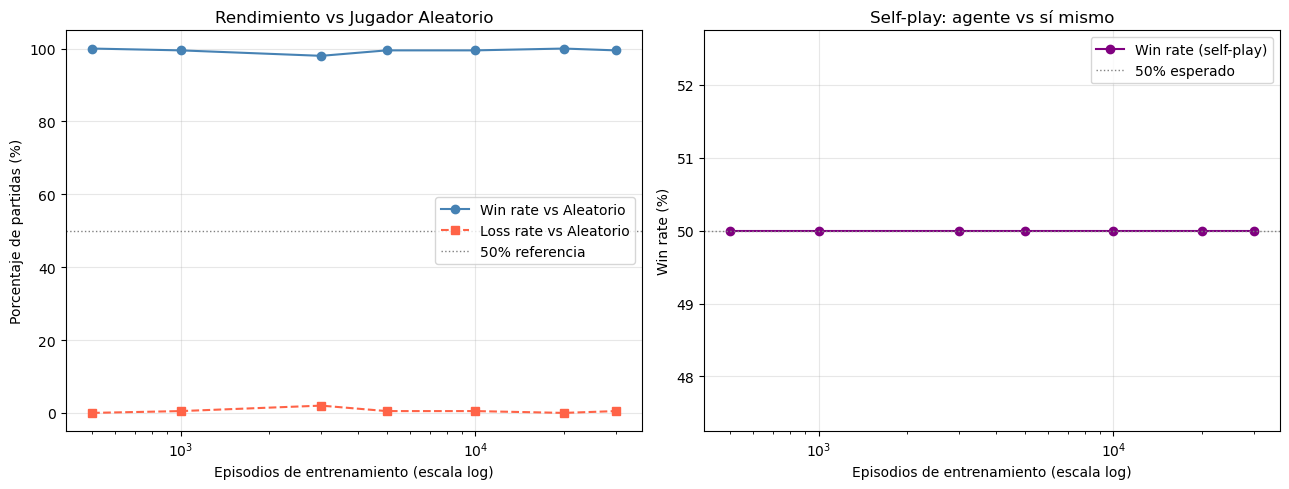

Figura guardada: curva_episodios.png


In [9]:
eps, wr, lr = zip(*results_vs_random)
eps_s, ws   = zip(*results_vs_self)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Izquierda: vs Aleatorio ---
axes[0].plot(eps, wr, 'o-', color='steelblue', label='Win rate vs Aleatorio')
axes[0].plot(eps, lr, 's--', color='tomato',   label='Loss rate vs Aleatorio')
axes[0].axhline(50, color='gray', linestyle=':', linewidth=1, label='50% referencia')
axes[0].set_xscale('log')
axes[0].set_xlabel('Episodios de entrenamiento (escala log)')
axes[0].set_ylabel('Porcentaje de partidas (%)')
axes[0].set_title('Rendimiento vs Jugador Aleatorio')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Derecha: Self-play ---
axes[1].plot(eps_s, ws, 'o-', color='purple', label='Win rate (self-play)')
axes[1].axhline(50, color='gray', linestyle=':', linewidth=1, label='50% esperado')
axes[1].set_xscale('log')
axes[1].set_xlabel('Episodios de entrenamiento (escala log)')
axes[1].set_ylabel('Win rate (%)')
axes[1].set_title('Self-play: agente vs sí mismo')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curva_episodios.png', dpi=150)
plt.show()
print('Figura guardada: curva_episodios.png')

## 4. Análisis: con vs sin heurística de fallback
Comparación de dos versiones del agente (con y sin la heurística cuando el estado no fue visitado).

In [10]:
# Agente SIN heurística: fallback aleatorio
class QLearningNoHeuristic(QLearningAgent):
    def act(self, s):
        free = get_free_cols(s)
        counts = {-1: int(np.sum(s==-1)), 1: int(np.sum(s==1))}
        me  = -1 if counts[-1] <= counts[1] else 1
        opp = -me

        # ganar en 1
        from policy import _drop, _check_winner
        for col in free:
            if _check_winner(_drop(s, col, me)) == me: return col
        # bloquear
        for col in free:
            if _check_winner(_drop(s, col, opp)) == opp: return col

        key = s.tobytes()
        if key in self.q_table:
            return self._best_q_col(key, free)

        # SIN heurística: aleatorio
        return int(np.random.choice(free))

agent_full = agent  # agente base ya entrenado
agent_noh  = QLearningNoHeuristic(episodes=30_000, save_path='q_table_30k.pkl')
agent_noh.mount()

r_full = run_matches(agent_full, random_agent, n=300)
r_noh  = run_matches(agent_noh,  random_agent, n=300)

print('Con heurística:  win={:.1f}%  loss={:.1f}%'.format(
    r_full['wins_a']/300*100, r_full['wins_b']/300*100))
print('Sin heurística:  win={:.1f}%  loss={:.1f}%'.format(
    r_noh['wins_a']/300*100,  r_noh['wins_b']/300*100))

Con heurística:  win=99.7%  loss=0.3%
Sin heurística:  win=98.0%  loss=2.0%


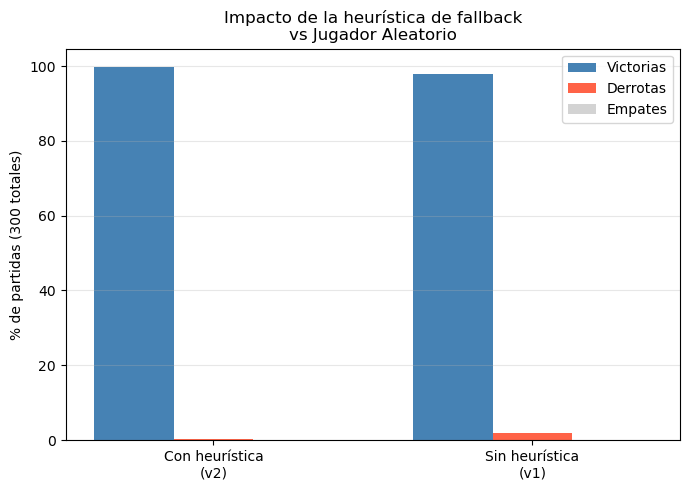

In [11]:
labels = ['Con heurística\n(v2)', 'Sin heurística\n(v1)']
wins_r   = [r_full['wins_a']/300*100, r_noh['wins_a']/300*100]
losses_r = [r_full['wins_b']/300*100, r_noh['wins_b']/300*100]
draws_r  = [r_full['draws']/300*100,  r_noh['draws']/300*100]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width, wins_r,   width, label='Victorias',  color='steelblue')
ax.bar(x,         losses_r, width, label='Derrotas',   color='tomato')
ax.bar(x + width, draws_r,  width, label='Empates',    color='lightgray')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% de partidas (300 totales)')
ax.set_title('Impacto de la heurística de fallback\nvs Jugador Aleatorio')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_heuristica.png', dpi=150)
plt.show()

## 5. Análisis por color (Rojo vs Amarillo)

In [12]:
def run_as_red(agent_a, agent_b, n=200):
    wins = losses = draws = 0
    for _ in range(n):
        w = play_game(agent_a, agent_b)  # a=Rojo
        if w==-1: wins+=1
        elif w==1: losses+=1
        else: draws+=1
    return wins/n, losses/n, draws/n

def run_as_yellow(agent_a, agent_b, n=200):
    wins = losses = draws = 0
    for _ in range(n):
        w = play_game(agent_b, agent_a)  # a=Amarillo
        if w==1: wins+=1
        elif w==-1: losses+=1
        else: draws+=1
    return wins/n, losses/n, draws/n

wr_red,  lr_red,  dr_red  = run_as_red(agent, random_agent)
wr_yel,  lr_yel,  dr_yel  = run_as_yellow(agent, random_agent)

print(f'Como Rojo    (-1): win={wr_red*100:.1f}%  loss={lr_red*100:.1f}%  draw={dr_red*100:.1f}%')
print(f'Como Amarillo (1): win={wr_yel*100:.1f}%  loss={lr_yel*100:.1f}%  draw={dr_yel*100:.1f}%')

Como Rojo    (-1): win=100.0%  loss=0.0%  draw=0.0%
Como Amarillo (1): win=100.0%  loss=0.0%  draw=0.0%


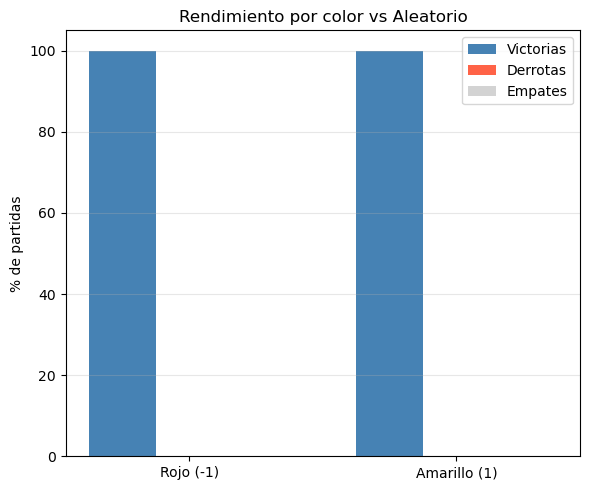

In [13]:
colors_label = ['Rojo (-1)', 'Amarillo (1)']
wins_c   = [wr_red*100, wr_yel*100]
losses_c = [lr_red*100, lr_yel*100]
draws_c  = [dr_red*100, dr_yel*100]

x = np.arange(2)
width = 0.25
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x-width, wins_c,   width, label='Victorias', color='steelblue')
ax.bar(x,       losses_c, width, label='Derrotas',  color='tomato')
ax.bar(x+width, draws_c,  width, label='Empates',   color='lightgray')
ax.set_xticks(x)
ax.set_xticklabels(colors_label)
ax.set_ylabel('% de partidas')
ax.set_title('Rendimiento por color vs Aleatorio')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rendimiento_por_color.png', dpi=150)
plt.show()

## 6. Tabla resumen de estados aprendidos

In [14]:
print(f"{'Episodios':>12} | {'Estados Q':>12}")
print('-' * 28)
for ep in episode_counts:
    save = f'q_table_{ep}.pkl'
    if os.path.exists(save):
        with open(save,'rb') as f:
            qt = pickle.load(f)
        print(f"{ep:>12,} | {len(qt):>12,}")

   Episodios |    Estados Q
----------------------------
         500 |        9,143
       1,000 |       18,456
       3,000 |       52,047
       5,000 |       85,817
      10,000 |      161,732
      20,000 |      316,566
      30,000 |      460,794


## 7. Conclusiones y propuestas de mejora

### Conclusiones
- El agente Q-learning supera consistentemente al jugador aleatorio para ambos colores desde los primeros 500 episodios, manteniéndose por encima del 98% de victorias en todos los niveles de entrenamiento probados
- La heurística de fallback mejora el desempeño en estados no visitados (ver Sección 4).
- En self-play el win-rate converge cerca del 50%, lo esperado cuando ambos jugadores tienen la misma política.
- La tabla Q crece de forma aproximadamente lineal con los episodios (de 9,143 estados con 500 episodios a 460,794 con 30,000), lo que sugiere que el espacio de estados explorado sigue expandiéndose y que entrenar con más episodios podría seguir aportando cobertura.

### Limitaciones identificadas
1. **Explosión de estados**: Con 30,000 episodios se cubren 460,794 estados, pero el espacio total de Connect-4 es del orden de 10¹² posiciones, menos del 0.0001% del espacio está en la tabla.
2. **Recompensa escasa**: la señal de recompensa solo llega al final de la partida, haciendo lento el aprendizaje de estrategias a largo plazo.
3. **Self-play puro**: el agente no fue entrenado contra oponentes más fuertes, lo que limita qué estrategias aprende.

### Propuestas de mejora
| Debilidad | Mejora propuesta | Efecto esperado |
|---|---|---|
| Explosión de estados | Usar una red neuronal para aproximar Q (Deep Q-Network) | Generalizar a estados no vistos |
| Recompensa escasa | Añadir recompensa intermedia basada en la heurística (reward shaping) | Aprendizaje más rápido y preciso |
| Self-play puro | Entrenar contra agentes con distintos niveles de profundidad (curriculum learning) | Estrategias más robustas |